In [1]:
%load_ext autoreload
%autoreload 2
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from YParams import YParams
from utils import *
from data_utils.data_loaders import *

In [2]:
params = YParams('./config/ssl_ns_elastic.yaml', 'codano_test', print_params=False)

In [3]:
mesh = get_mesh(params.input_mesh_location)

In [4]:
mesh.shape

(4858, 2)

In [5]:
print(list(params.equation_dict.keys()))
dataset = NsElasticDataset(params.data_location, equation=list(params.equation_dict.keys()), mesh_location=params.input_mesh_location)
params.dt = 100
train, test = dataset.get_dataloader(params.mu_list, params.dt, ntrain=params.get(
        'ntrain'), ntest=params.get('ntest'), sample_per_inlet=params.sample_per_inlet)

['NS']
Means:  None
stds  None


Loaded tensor Size: torch.Size([1001, 4858, 3])
Loaded tensor Size: torch.Size([1001, 4858, 1])
Loaded tensor Size: torch.Size([1001, 4858, 3])
Means:  tensor([ 2.4033e-01, -6.4943e-03,  1.9696e+03,  0.0000e+00, -1.2430e-19])
stds  tensor([2.8160e-01, 8.4722e-02, 1.2377e+03, 0.0000e+00, 1.2683e-17])
Loaded tensor Size: torch.Size([1001, 4858, 3])
Loaded tensor Size: torch.Size([1001, 4858, 1])
Loaded tensor Size: torch.Size([1001, 4858, 3])
Means:  tensor([ 2.5333e-01, -9.1753e-03,  2.0458e+03,  0.0000e+00, -1.8100e-19])
stds  tensor([2.9072e-01, 8.9846e-02, 1.2311e+03, 0.0000e+00, 1.5073e-17])
Loaded tensor Size: torch.Size([1001, 4858, 3])
Loaded tensor Size: torch.Size([1001, 4858, 1])
Loaded tensor Size: torch.Size([1001, 4858, 3])
Means:  tensor([ 2.5166e-01, -2.0083e-02,  2.0924e+03,  0.0000e+00,  2.4105e-19])
stds  tensor([2.8831e-01, 1.0215e-01, 1.2180e+03, 0.0000e+00, 2.0726e-17])
Loaded tensor Size: torch.Size([1001, 4858, 3])
Loaded tensor Size: torch.Size([1001, 4858, 1])
L

In [6]:
mesh = torch.from_numpy(mesh).float()
print(mesh.shape)

torch.Size([4858, 2])


torch.Size([4858, 2]) torch.Size([4858, 2]) torch.Size([4858, 2]) torch.Size([1, 4858, 3]) torch.Size([1, 4858, 3])
tensor(0.) tensor(0.)


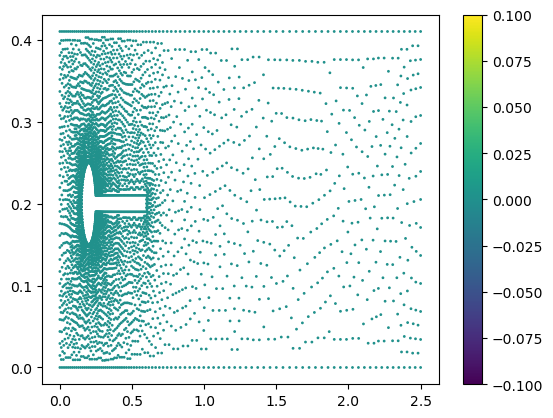

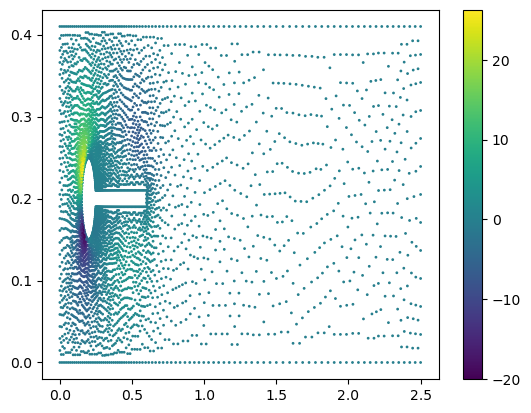

In [7]:
for data in train:
    x, y = data['x'], data['y']
    dx_mesh = data['d_grid_x'][0]
    dy_mesh = data['d_grid_y'][0]
    print(mesh.shape, dx_mesh.shape, dy_mesh.shape, x.shape,y.shape)
    print(torch.min(dx_mesh[:,0]), torch.min(dx_mesh[:,1]))
    plt.scatter(mesh[:,0]+dx_mesh[:,0], mesh[:,1]+dx_mesh[:,1],c=dx_mesh[:,0], cmap='viridis', s=1.0)
    plt.colorbar()
    plt.show()
    plt.scatter(mesh[:,0]+dy_mesh[:,0], mesh[:,1]+dy_mesh[:,1],c=y[0,:,-2], cmap='viridis', s=1.0)
    plt.colorbar()
    plt.show()

In [26]:
_, mask = masker((1317, 7),max_block=0.7, drop_pix=0.3,\
                 channel_aug_rate = 0.8, channel_drop_rate = 0.4, device='cuda', min_block=10, max_blocks=100 )

In [27]:
mask[:,1]

tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0')

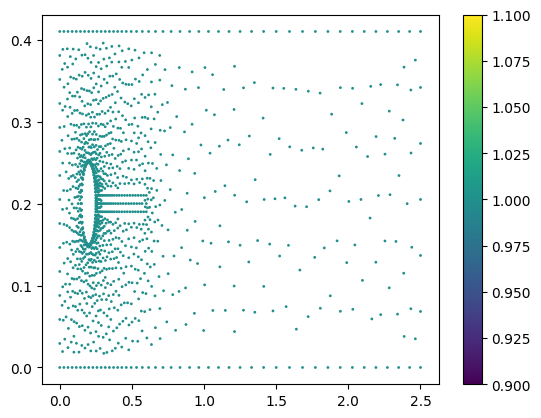

In [28]:
plt.scatter(mesh[0,:], mesh[1:],c=mask[:,4].cpu(), cmap='viridis', s=1.0)
plt.colorbar()

In [29]:
f

tensor([0.0000, 0.1681, 6.4181,  ..., 0.1098, 0.1204, 0.1166])

In [30]:
f[masker.in_nbr[-1].long()==1] = 0

In [12]:
import h5py

# Specify the path to your HDF5 file
file_path = '../Data/TF_fsi2_results/mesh.h5'

h5f = h5py.File(file_path, 'r')

ds_data = h5f['mesh/coordinates']
print(ds_data.shape, ds_data.dtype)

(1317, 2) float64


In [ ]:
boundaries
boundaries/coordinates
boundaries/topology
  celltype: b'interval'
  partition: [0]
boundaries/values
domains
domains/cell_indices
domains/coordinates
domains/topology
  celltype: b'triangle'
  partition: [0]
domains/values
mesh
mesh/cell_indices
mesh/coordinates
mesh/topology
  celltype: b'triangle'
  partition: [0]